# PCL Detection

DeBERTa-v3-base + Weighted Loss + Threshold Tuning

In [1]:
# For Colab:
!pip install transformers torch scikit-learn pandas matplotlib seaborn

In [2]:
# To run on Colab or local:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    COLAB_MODE = True
    print("Google Drive mounted successfully!")
except ImportError:
    COLAB_MODE = False
    print("Not running in Colab (local mode)")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 1. Setup and imports

In [4]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42 #use to reprduce results
ENSEMBLE_SEEDS = [42, 69, 140, 2, 21]
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. Data Loading and preprocessing

In [5]:
if COLAB_MODE:
    DATA_DIR = "/content/drive/My Drive/pcl-classification-cw/data"
else:
    DATA_DIR = "../data"
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

# --- Load the full dataset ---
df_full = pd.read_csv(
    os.path.join(DATA_DIR, "raw", "dontpatronizeme_pcl.tsv"),
    sep="\t",
    skiprows=3,
    header=None,
)
df_full.columns = ["par_id", "art_id", "keyword", "country", "text","label"]

#binarise the labels as did previously...
df_full["binary_label"] = (df_full["label"] >= 2).astype(int)

print(f"Full dataset: {len(df_full)} samples")
print(f"Label distribution:\n{df_full['binary_label'].value_counts()}")

Full dataset: 10469 samples
Label distribution:
binary_label
0    9476
1     993
Name: count, dtype: int64


In [6]:
# --- Load train/dev splits ---
train_split = pd.read_csv(os.path.join(SPLITS_DIR, "official_train.csv"))
dev_split =pd.read_csv(os.path.join(SPLITS_DIR, "official_dev.csv"))

#Use left merge to preserve parid ordering:
df_train_official = train_split[["par_id"]].merge(
    df_full[["par_id", "text", "binary_label"]],
    on="par_id",
    how="left",
)
df_dev_official = dev_split[["par_id"]].merge(
    df_full[["par_id", "text", "binary_label"]],
    on="par_id",
    how="left",
)

print(f"Train = {len(df_train_official)} samples")
print(f"Dev = {len(df_dev_official)} samples")

print(f"\nTrain label distribution:\n{df_train_official['binary_label'].value_counts()}")
print(f"\nDev label distribution:\n{df_dev_official['binary_label'].value_counts()}")

Train = 8375 samples
Dev = 2094 samples

Train label distribution:
binary_label
0    7581
1     794
Name: count, dtype: int64

Dev label distribution:
binary_label
0    1895
1     199
Name: count, dtype: int64


In [7]:
# --- Create train/val split from train set ... for hyperparameter tuning ---
# use stratify to maintain equal distr in train/val splits
df_train, df_val = train_test_split(
    df_train_official,
    test_size=0.1, #90/10 split
    stratify=df_train_official["binary_label"],
    random_state=SEED,
)

print(f"Train: {len(df_train)} samples")
print(f"Val:   {len(df_val)} samples")

Train: 7537 samples
Val:   838 samples


In [8]:
# load official test set ---
df_test_official = pd.read_csv(
    os.path.join(SPLITS_DIR, "official_test.csv"),
    sep="\t",
    header=None,
)
df_test_official.columns = ["par_id", "art_id","keyword", "country", "text"]

print(f"Official test set: {len(df_test_official)} samples")
df_test_official.head()

Official test set: 3832 samples


,par_id,art_id,keyword,country,text
0,t_0,@@7258997,vulnerable,us,"In the meantime , conservatives are working to..."
1,t_1,@@16397324,women,pk,In most poor households with no education chil...
2,t_2,@@16257812,migrant,ca,The real question is not whether immigration i...
3,t_3,@@3509652,migrant,gb,"In total , the country 's immigrant population..."
4,t_4,@@477506,vulnerable,ca,"Members of the church , which is part of Ken C..."


## 3. Tokenisation

In [9]:
MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256 #based on EDA of text lengths

class PCLDataset(Dataset):
    # Create our custom dataset for this task - to be used by 'Trainer' later...

    def __init__(self, texts, labels=None, tokenizer=None, max_length=256):
        self.texts = texts.tolist() if hasattr(texts, "tolist") else list(texts)
        self.labels = labels.tolist() if labels is not None and hasattr(labels, "tolist") else labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [10]:
# Create datasets
train_dataset = PCLDataset(df_train["text"], df_train["binary_label"],tokenizer, MAX_LENGTH)
val_dataset = PCLDataset(df_val["text"], df_val["binary_label"],tokenizer, MAX_LENGTH)
dev_dataset = PCLDataset(df_dev_official["text"], df_dev_official["binary_label"],tokenizer, MAX_LENGTH)
test_dataset = PCLDataset(df_test_official["text"], labels=None,tokenizer=tokenizer,max_length=MAX_LENGTH)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")
print(f"Dev dataset: {len(dev_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

Train dataset: 7537 samples
Val dataset: 838 samples
Dev dataset: 2094 samples
Test dataset: 3832 samples


In [11]:
# --- Compute class weights ---
labels_array = np.array(df_train["binary_label"].tolist())
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels_array) #the true balanced weights
print(f"Computed balanced weights: No PCL={weights[0]:.4f}, PCL={weights[1]:.4f}")

class_weights = torch.tensor([1.0, 3.0], dtype=torch.float32).to(device) # the weights we actually use (capped to avoid instability)
print(f"Using class weights: No PCL={class_weights[0]:.4f}, PCL={class_weights[1]:.4f}")

Computed balanced weights: No PCL=0.5524, PCL=5.2706
Using class weights: No PCL=1.0000, PCL=3.0000


## 6. Model and Traininig

In [12]:
# Load pretrained DeBERTa-v3
N_ENSEMBLE = len(ENSEMBLE_SEEDS)
all_val_logits = []
all_dev_logits = []
all_test_logits = []

_tmp = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print(f"Ensemble of {N_ENSEMBLE} DeBERTa-v3-base models (seeds: {ENSEMBLE_SEEDS})")
print(f"Model parameters per model: {sum(p.numel() for p in _tmp.parameters()):,}")
del _tmp

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

Ensemble of 5 DeBERTa-v3-base models (seeds: [42, 69, 140, 2, 21])
Model parameters per model: 184,423,682


In [13]:
def make_weighted_loss_fn(class_weights):
    # Create the weighted crossentropy loss func:
    def weighted_loss(outputs, labels, num_items_in_batch=None):
        logits = outputs.logits if hasattr(outputs, "logits") else outputs[1]
        weights_cast = class_weights.to(dtype=logits.dtype, device=logits.device)
        labels = labels.to(torch.long)
        loss_fn =nn.CrossEntropyLoss(weight=weights_cast)
        return loss_fn(logits, labels)
    return weighted_loss

weighted_loss_fn = make_weighted_loss_fn(class_weights)

def compute_metrics(eval_pred):
    # Create F1 scoring for scoring during training:
    logits, labels = eval_pred
    preds = np.argmax(logits,axis=1)
    f1 = f1_score(labels, preds, pos_label=1)
    return {"f1": f1}

In [14]:
OUTPUT_DIR = "../models/deberta_pcl_v2"

In [15]:
print("Starting training...")

for i, seed in enumerate(ENSEMBLE_SEEDS):
    print(f"\n{'='*60}")
    print(f"  Model {i+1}/{N_ENSEMBLE}  (seed={seed})")
    print(f"{'='*60}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
    )
    model = model.float()
    model.to(device)

    training_args = TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/seed_{seed}",
        num_train_epochs=5,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        max_grad_norm=1.0,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        bf16=True,
        seed=seed,
        report_to="none",
        save_total_limit=1,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        compute_loss_func=weighted_loss_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    val_result = trainer.evaluate(val_dataset)
    print(f"  Seed {seed} — Val F1: {val_result['eval_f1']:.4f}")

    all_val_logits.append(trainer.predict(val_dataset).predictions)
    all_dev_logits.append(trainer.predict(dev_dataset).predictions)
    all_test_logits.append(trainer.predict(test_dataset).predictions)

    del model, trainer
    torch.cuda.empty_cache()

print(f"\nAll {N_ENSEMBLE} models trained. Ensembling predictions...")

Starting training...

  Model 1/5  (seed=42)


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

Epoch,Training Loss,Validation Loss,F1
1,0.868296,0.492480,0.428571
2,0.856996,0.498130,0.428571
3,0.593403,0.611988,0.446043
4,0.806632,0.510369,0.455882
5,0.589004,0.517244,0.484848


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

  Seed 21 — Val F1: 0.4270



All 5 models trained. Ensembling predictions...


## 7. Evaluation

Evaluate on dev set before threshold tuning:

In [16]:
dev_logits = np.mean(np.stack(all_dev_logits), axis=0)
dev_labels = df_dev_official["binary_label"].values

# Default threshold
dev_preds_default = np.argmax(dev_logits, axis=1)
f1_default = f1_score(dev_labels, dev_preds_default, pos_label=1)
print(f"Dev F1 (threshold=0.5): {f1_default:.4f}")
print(f"\nClassification Matrix:")
print(classification_report(dev_labels, dev_preds_default, target_names=["No PCL", "PCL"]))

Dev F1 (threshold=0.5): 0.4692

Classification Matrix:
              precision    recall  f1-score   support

      No PCL       0.95      0.93      0.94      1895
         PCL       0.44      0.50      0.47       199

    accuracy                           0.89      2094
   macro avg       0.70      0.72      0.70      2094
weighted avg       0.90      0.89      0.90      2094



## 8. Threshold Tuning

The threshold is tuned on the validation set and then applied to the 'held out' official dev set to give an unbiased F1 estimate:

Best threshold (val set):              0.38
Val F1 at best threshold:              0.4740
Dev F1:                               0.4807
Improvement over default (dev):        0.0115


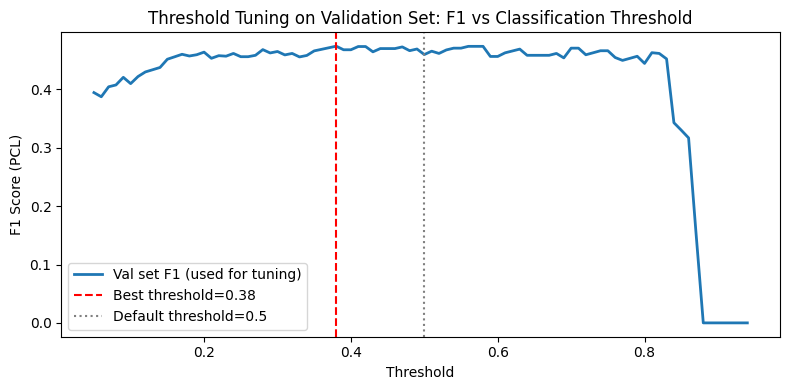

In [17]:
# Compute softmax prob. for the positive class on the dev set...
dev_probs = torch.softmax(torch.tensor(dev_logits), dim=1)[:, 1].numpy()

val_logits = np.mean(np.stack(all_val_logits), axis=0)
val_probs  = torch.softmax(torch.tensor(val_logits), dim=1)[:, 1].numpy()
val_labels = np.array(df_val["binary_label"].tolist())

thresholds = np.arange(0.05, 0.95, 0.01)
val_f1_scores = []
# sweep thresholds...
for t in thresholds:
    preds = (val_probs>=t).astype(int)
    val_f1_scores.append(f1_score(val_labels, preds, pos_label=1, zero_division=0))

best_idx = int(np.argmax(val_f1_scores))
best_threshold = thresholds[best_idx]

# Apply best threshold to dev set:
dev_preds_tuned = (dev_probs>=best_threshold).astype(int)
best_f1 = f1_score(dev_labels, dev_preds_tuned, pos_label=1)

print(f"Best threshold (val set):              {best_threshold:.2f}")
print(f"Val F1 at best threshold:              {val_f1_scores[best_idx]:.4f}")
print(f"Dev F1:                               {best_f1:.4f}")
print(f"Improvement over default (dev):        {best_f1 - f1_default:.4f}")

# Plot F1 vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, val_f1_scores, linewidth=2, label="Val set F1 (used for tuning)")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold={best_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold=0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score (PCL)")
ax.set_title("Threshold Tuning on Validation Set: F1 vs Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()


--- Final Dev Set Results (threshold=0.38 ) ---
              precision    recall  f1-score   support

      No PCL       0.95      0.92      0.93      1895
         PCL       0.42      0.56      0.48       199

    accuracy                           0.88      2094
   macro avg       0.69      0.74      0.71      2094
weighted avg       0.90      0.88      0.89      2094



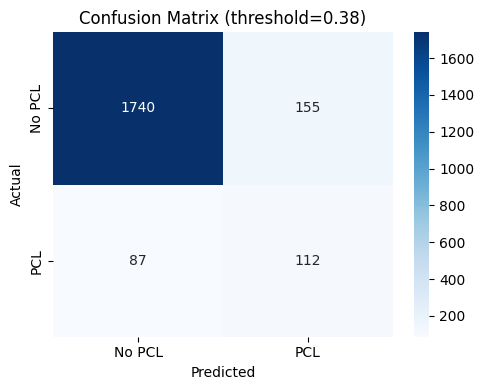

In [18]:
#Final dev set evaluation with optimised threshold
dev_preds_final = (dev_probs>=best_threshold).astype(int)

print(f"\n--- Final Dev Set Results (threshold={best_threshold:.2f} ) ---")
print(classification_report(dev_labels, dev_preds_final, target_names=["No PCL", "PCL"]))

# Confusion matrix:
cm = confusion_matrix(dev_labels, dev_preds_final)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No PCL", "PCL"], yticklabels=["No PCL", "PCL"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

## 9. Predictions

- `dev.txt` —> predictions follow `official_dev.csv` par_id order
- `test.txt` —> predictions follow `official_test.csv` line order

In [19]:
dev_preds_submission = (dev_probs>=best_threshold).astype(int)

if COLAB_MODE:
    pred_dir = "/content/drive/My Drive/pcl-classification-cw/predictions"
else:
    pred_dir = "../predictions"
os.makedirs(pred_dir, exist_ok=True)

dev_output_path = os.path.join(pred_dir, "dev.txt")

np.savetxt(dev_output_path, dev_preds_submission, fmt="%d")
print(f"Dev predictions saved to {dev_output_path}")
print(f"Lines = {len(dev_preds_submission)}")
print(f"PCL predictions= {dev_preds_submission.sum()} ({dev_preds_submission.mean()*100:.1f}%)")

Dev predictions saved to /content/drive/My Drive/pcl-classification-cw/predictions/dev.txt
Lines = 2094
PCL predictions= 267 (12.8%)


In [20]:
# --- Test set predictions ---
test_logits = np.mean(np.stack(all_test_logits), axis=0)
test_probs = torch.softmax(torch.tensor(test_logits), dim=1)[:, 1].numpy()
test_preds = (test_probs >= best_threshold).astype(int)

test_output_path = os.path.join(pred_dir, "test.txt")

np.savetxt(test_output_path, test_preds, fmt="%d")
print(f"Test predictions saved to {test_output_path}")
print(f"Lines = {len(test_preds)}")
print(f"PCL predictions= {test_preds.sum()} ({test_preds.mean()*100:.1f}%)")

Test predictions saved to /content/drive/My Drive/pcl-classification-cw/predictions/test.txt
Lines = 3832
PCL predictions= 424 (11.1%)


In [21]:
# Verify output format
assert len(dev_preds_submission) == len(df_dev_official), \
    f"Dev predictions count mismatch: {len(dev_preds_submission)} vs {len(df_dev_official)}"
assert len(test_preds) == len(df_test_official), \
    f"Test predictions count mismatch: {len(test_preds)} vs {len(df_test_official)}"
assert len(test_preds) == 3832, f"Test predictions should be 3832 lines, got {len(test_preds)}"
print(f"Both prediction files have correct number of lines.")
print(f" ... dev.txt:  {len(dev_preds_submission)} predictions")
print(f" ... test.txt: {len(test_preds)} predictions")

Both prediction files have correct number of lines.
 ... dev.txt:  2094 predictions
 ... test.txt: 3832 predictions


In [22]:
#  ---- SAVE MODELS AND TOKENIZER ---

import json

if COLAB_MODE:
    SAVE_DIR = "/content/drive/My Drive/pcl-classification-cw/models/best_deberta_pcl_v2"
else:
    SAVE_DIR = "../models/best_deberta_pcl_v2"

os.makedirs(SAVE_DIR, exist_ok=True)
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "config_extra.json"), "w") as f:
    json.dump({
        "ensemble_seeds": ENSEMBLE_SEEDS,
        "n_models": N_ENSEMBLE,
        "best_threshold": float(best_threshold),
        "dev_f1_default": float(f1_default),
        "dev_f1_tuned": float(best_f1),
    }, f, indent=2)

print(f"Model saved to {SAVE_DIR}")
print(f"Ensemble: {N_ENSEMBLE} models (seeds: {ENSEMBLE_SEEDS})")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Dev F1 (default): {f1_default:.4f}")
print(f"Dev F1 (tuned): {best_f1:.4f}")

Model saved to /content/drive/My Drive/pcl-classification-cw/models/best_deberta_pcl_v2
Ensemble: 5 models (seeds: [42, 69, 140, 2, 21])
Best threshold: 0.38
Dev F1 (default): 0.4692
Dev F1 (tuned): 0.4807


---
## 10. Exercise 5.2 – Local Evaluation

### 10a. Error Analysis

Inspect false positives and false negatives to identify linguistic patterns in the failures...

In [23]:
import textwrap

fp_mask = (dev_preds_final == 1) & (dev_labels == 0) # = False positives
fn_mask = (dev_preds_final == 0) & (dev_labels == 1) # = False negatives
fp_indices = np.where(fp_mask)[0]
fn_indices = np.where(fn_mask)[0]

print(f"False Positives = {fp_mask.sum()}")
print(f"False Negatives = {fn_mask.sum()}")

False Positives = 155
False Negatives = 87


In [24]:
def print_examples(indices, label, dev_df, probs, n=5):
    """Print n error examples sorted by model confidence (most confident errors first)."""
    #sort by probability descending
    sorted_by_confidence = sorted(indices, key=lambda i: probs[i], reverse=True)
    print(f"\n{'='*70}")
    print(f" {label}  (showing {min(n, len(sorted_by_confidence))} of {len(sorted_by_confidence)})")
    print(f"{'='*70}")
    for rank, idx in enumerate(sorted_by_confidence[:n], 1):
        text = dev_df.iloc[idx]["text"]
        prob = probs[idx]
        wrapped = textwrap.fill(str(text), width=70)
        print(f"\n{rank}) PCL probability: {prob:.3f}")
        print(wrapped)

# - PRINT FALSE POSITIVES –
print_examples(
    fp_indices,
    "FALSE POSITIVES",
    df_dev_official, dev_probs
)


 FALSE POSITIVES  (showing 5 of 155)

1) PCL probability: 0.874
Christmas is celebration of the birth of not merely a child , but a
child who changed the destiny of humans forever . It is celebration of
the fact that God wanted to be a part of the human race and so he took
on flesh and blood and became human like us . We can also show
unconditional love through our good deeds and helping those who are in
need of our help and care . Be human and merciful .

2) PCL probability: 0.874
Adopt a Mission serves as a platform for the church and for likeminded
people to reach out to unemployed families in the communities --
whoever is in need . " <h> The forgotten people of Brooklyn

3) PCL probability: 0.874
In his condolence message , he said , " All our sympathies are with
the poor families as we are standing in cohesion with the Egyptian
government and the people in this hour of grief . "

4) PCL probability: 0.874
Columns <h> Poor , pregnant and homeless

5) PCL probability: 0.874
But he 

In [25]:
# - PRINT FALSE NEGATIVES –
print_examples(
    fn_indices,
    "FALSE NEGATIVES",
    df_dev_official, dev_probs
)


 FALSE NEGATIVES  (showing 5 of 87)

1) PCL probability: 0.370
Old BC : As usual , Old GB has it assy-versy . I think there should be
more focus on preventing homelessness than curing it . Are there
systems for actually going out , picking up the homeless , and placing
them where they belong ? Homeless people are n't voluntarily walking
into these shelters .

2) PCL probability: 0.364
Jamaicans are deemed to be among the most violent persons on planet
Earth . Some argue that it has to do with our legacy of slavery which
in itself was an act of extreme violence . Some even posit that it may
well be that we have too much sugar in our blood ; while others point
to the socio-economic conditions that the majority of black Jamaicans
have to live under which have led them to a point of hopelessness and
anger .

3) PCL probability: 0.361
Emmanuelle Riva in " Amour , " as a woman in her 80s whose mind and
body deteriorate after a series of strokes , is even frailer , more
vulnerable , and quit

### 10b. Ablation Study

Compare our ensemble model vs a single model (weighted):

In [26]:
from transformers import TrainingArguments, Trainer

# Load a fresh model with identical archtecture... BUT not 5-model ensemble:
SINGLE_EPOCHS = 5

print(f"Training single weighted model (seed={SEED}, {SINGLE_EPOCHS} epochs)...")

torch.manual_seed(SEED)
np.random.seed(SEED)

single_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
single_model = single_model.float()
single_model.to(device)

single_training_args = TrainingArguments(
    output_dir              = f"/tmp/single_model/seed_{SEED}",
    num_train_epochs        = SINGLE_EPOCHS,
    per_device_train_batch_size  = 8,
    gradient_accumulation_steps  = 2,
    per_device_eval_batch_size   = 16,
    learning_rate           = 2e-5,
    warmup_ratio            = 0.1,
    weight_decay            = 0.01,
    max_grad_norm           = 1.0,
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "f1",
    greater_is_better       = True,
    logging_steps           = 50,
    bf16                    = True,
    seed                    = SEED,
    report_to               = "none",
    save_total_limit        = 1,
)

single_trainer = Trainer(
    model           = single_model,
    args            = single_training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    compute_loss_func=weighted_loss_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

single_trainer.train()

val_result = single_trainer.evaluate(val_dataset)
print(f"  Seed {SEED} — Val F1: {val_result['eval_f1']:.4f}")

single_val_logits = single_trainer.predict(val_dataset).predictions
single_dev_logits = single_trainer.predict(dev_dataset).predictions

del single_model, single_trainer
torch.cuda.empty_cache()

print(f"\nSingle weighted model trained.")

Training single weighted model (seed=42, 5 epochs)...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

Epoch,Training Loss,Validation Loss,F1
1,0.937916,0.487554,0.343490
2,0.854550,0.592077,0.451613
3,0.518688,0.588450,0.471429
4,0.652850,0.592181,0.466258
5,0.611037,0.724427,0.465409


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

  Seed 42 — Val F1: 0.4714



Single weighted model trained.


In [29]:
# --- Evaluate unweighted model ---

# Get val set predictions for threshold tuning
single_val_probs = torch.softmax(
    torch.tensor(single_val_logits, dtype=torch.float32), dim=1
)[:, 1].numpy()

# Get dev set predictions for final evaluation
single_dev_probs = torch.softmax(
    torch.tensor(single_dev_logits, dtype=torch.float32), dim=1
)[:, 1].numpy()


single_preds_default = np.argmax(single_dev_logits, axis=1)
single_f1_default = f1_score(dev_labels, single_preds_default, pos_label=1, zero_division=0)

# Tune threshold on val set:
thresh_range = np.arange(0.05, 0.95, 0.01)
single_f1_scores = [
    f1_score(val_labels, (single_val_probs >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresh_range
]
single_best_thresh = thresh_range[int(np.argmax(single_f1_scores))]

# Apply val-tuned threshold to dev set...
single_preds_tuned = (single_dev_probs>=single_best_thresh).astype(int)
single_best_f1 = f1_score(dev_labels, single_preds_tuned, pos_label=1, zero_division=0)

print("--- Single weighted model ---")
print(classification_report(dev_labels, single_preds_tuned, target_names=["No PCL", "PCL"], zero_division=0))
print(f"Best threshold (val set) = {single_best_thresh:.2f}")
print(f"Dev F1 (val-tuned threshold)= {single_best_f1:.4f}")

--- Single weighted model ---
              precision    recall  f1-score   support

      No PCL       0.95      0.94      0.94      1895
         PCL       0.45      0.50      0.47       199

    accuracy                           0.89      2094
   macro avg       0.70      0.72      0.71      2094
weighted avg       0.90      0.89      0.90      2094

Best threshold (val set) = 0.13
Dev F1 (val-tuned threshold)= 0.4737


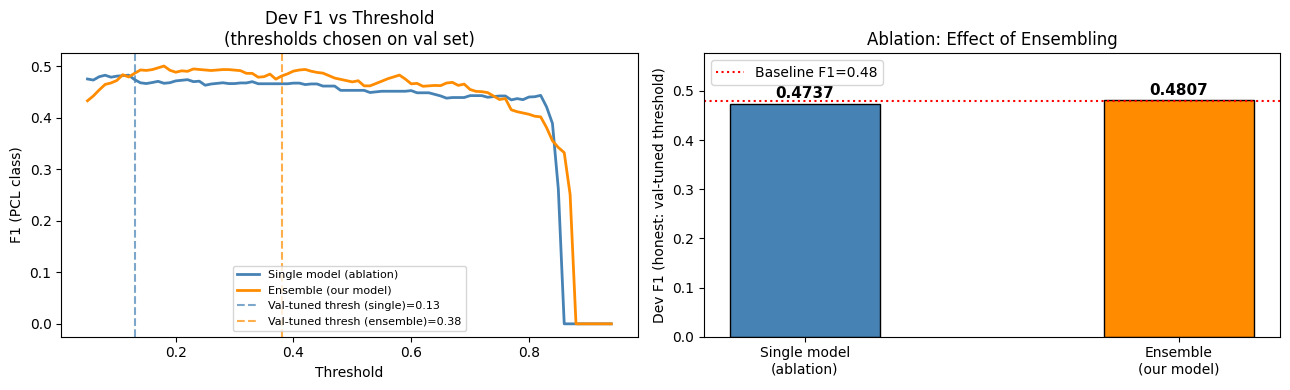

Baseline (RoBERTa, official):  F1 = 0.48
Single model ablation:         F1 = 0.4737  (val-tuned threshold=0.13)
Ensemble — our model:          F1 = 0.4807  (val-tuned threshold=0.38)

  Ensembling contribution:       +0.0070 F1


In [30]:
# --- Side by side comparison plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left plot: F1 vs threshold on the DEV SET
dev_weighted_f1_scores = [
    f1_score(dev_labels, (dev_probs >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresh_range
]
dev_single_f1_scores = [
    f1_score(dev_labels, (single_dev_probs >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresh_range
]
axes[0].plot(thresh_range, dev_single_f1_scores, label="Single model (ablation)", color="steelblue", linewidth=2)
axes[0].plot(thresh_range, dev_weighted_f1_scores, label="Ensemble (our model)", color="darkorange", linewidth=2)
axes[0].axvline(single_best_thresh, color="steelblue", linestyle="--", alpha=0.7, label=f"Val-tuned thresh (single)={single_best_thresh:.2f}")
axes[0].axvline(best_threshold, color="darkorange", linestyle="--", alpha=0.7, label=f"Val-tuned thresh (ensemble)={best_threshold:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F1 (PCL class)")
axes[0].set_title("Dev F1 vs Threshold\n(thresholds chosen on val set)")
axes[0].legend(fontsize=8)

# Right plot: Final dev F1 using tuned thresholds
models = ["Single model\n(ablation)", "Ensemble\n(our model)"]
f1_vals = [single_best_f1, best_f1]
colours = ["steelblue", "darkorange"]
bars = axes[1].bar(models, f1_vals, color=colours, width=0.4, edgecolor="black")
axes[1].axhline(0.48, color="red", linestyle=":", linewidth=1.5, label="Baseline F1=0.48")
for bar, val in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.4f}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_ylim(0, max(f1_vals) * 1.2)
axes[1].set_ylabel("Dev F1 (honest: val-tuned threshold)")
axes[1].set_title("Ablation: Effect of Ensembling")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Baseline (RoBERTa, official):  F1 = 0.48")
print(f"Single model ablation:         F1 = {single_best_f1:.4f}  (val-tuned threshold={single_best_thresh:.2f})")
print(f"Ensemble — our model:          F1 = {best_f1:.4f}  (val-tuned threshold={best_threshold:.2f})")
delta = best_f1 - single_best_f1
print(f"\n  Ensembling contribution:       +{delta:.4f} F1")